In [1]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
from __future__ import unicode_literals

import warnings
warnings.filterwarnings('ignore')
import numpy as np

from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import RandomSampler, SequentialSampler
from torch.optim.lr_scheduler import LambdaLR
import torch
from torch import nn
import torch.nn.functional as F
from torch import optim
from torch.autograd import Variable
from torch.cuda.amp import GradScaler, autocast

import tqdm
import pickle
import argparse
import random
import math
import os
import bisect
import numpy as np
import matplotlib.pyplot as plt
import dill


from sklearn.utils import shuffle



libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS


## 增强后的burst级别

In [2]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu", 0)

In [3]:
data = np.load('./datasets/awf1_aug2x.npz')

In [4]:
print(data.files)

['x_train', 'y_train']


In [5]:
key0 = data.files[0]
label = data.files[1]
keys = data[key0]
labels = data[label]
np.set_printoptions(threshold=np.inf)
print(keys[:1])
print(labels[0])

[[ 1.  1.  1. -1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  1.  1.  1.  1. -1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  1.  1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1.  1. -1. -1. -1. -1. -1. -1. -1. -1.  1.
  -1. -1. -1. -1. -1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  1.  1.  1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  1.  1.
   1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  1.  1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. 

In [8]:
def to_burst(trace, ignore_zero=True):
    burst = []

    prev = None
    cnt = 0

    for x in trace:
        x = int(x)

        if ignore_zero and x == 0:
            break          # 如果后面全是padding，可以直接break
            # continue     # 如果0可能出现在中间，就改成continue

        if prev is None:
            prev = x
            cnt = 1
        elif x == prev:
            cnt += 1
        else:
            burst.append(cnt if prev > 0 else -cnt)
            prev = x
            cnt = 1

    if cnt:
        burst.append(cnt if prev > 0 else -cnt)

    return burst

burst = to_burst(keys[0])
print(burst)
print(len(burst))

[3, -1, 58, -1, 15, -38, 1, -8, 1, -5, 20, -27, 3, -13, 2, -80, 1, -110, 2, -125, 46, -1, 6, -52, 1, -48, 2, -52, 2, -68, 2, -80, 2, -49, 1, -3, 2, -29, 8, -5, 5, -1, 1, -1, 1, -1, 2, -3, 4, -2, 1, -1, 1, -11, 1, -7, 1, -8, 2, -11, 1, -7, 1, -5, 2, -1, 1, -37, 1, -6, 1, -42, 3, -50, 2, -4, 1, -56, 2, -46, 2, -6, 1, -3, 1, -7, 4, -2, 1, -1, 1, -25, 1, -16, 1, -11, 1, -4, 1, -7, 12, -27, 1, -6, 1, -19, 2, -9, 1, -52, 1, -7, 2, -7, 2, -36, 2, -32, 2, -30, 2, -16, 2, -7, 2, -1, 3, -54, 2, -2, 1, -4, 1, -11, 1, -11, 4, -52, 2, -41, 1, -6, 9, -1, 1, -1, 10, -19, 1, -20, 2, -24, 1, -24, 1, -16, 2, -10, 6, -38, 2, -2, 2, -28, 1, -7, 2, -60, 1, -73, 2, -55, 4, -2, 1, -70, 2, -22, 1, -25, 1, -30, 2, -30, 2, -32, 2, -8, 2, -26, 1, -67, 2, -92, 4, -2, 2, -39, 2, -22, 1, -11, 1, -45, 1, -11, 2, -6, 4, -13, 2, -7, 5, -6, 2, -8, 2, -16, 2, -68, 2, -36, 2, -12, 2, -38, 1, -70, 2, -89, 2, -14, 4, -36, 1, -8, 2, -8, 2, -34, 1, -34, 2, -54, 2, -22, 2, -46, 2, -6, 4, -20, 2, -26, 2, -78, 2, -6, 2, -2, 2, 

In [10]:
burst = to_burst(keys[1])
print(burst)
print(len(burst))

[58, -1, 15, -46, 1, -5, 20, -40, 2, -80, 1, -110, 2, -125, 46, -1, 6, -52, 1, -48, 2, -52, 2, -68, 2, -24, 5, -56, 2, -52, 2, -8, 1, -21, 8, -5, 5, -1, 1, -1, 1, -1, 2, -3, 4, -2, 1, -1, 1, -18, 1, -19, 1, -7, 1, -5, 2, -1, 1, -37, 1, -6, 1, -42, 3, -40, 1, -10, 2, -4, 1, -56, 2, -15, 1, -31, 2, -6, 1, -3, 1, -7, 4, -2, 1, -1, 1, -25, 1, -22, 1, -5, 1, -11, 12, -33, 1, -28, 1, -52, 1, -14, 2, -36, 2, -62, 2, -12, 2, -11, 2, -1, 3, -43, 1, -11, 2, -2, 1, -15, 1, -63, 2, -41, 1, -6, 9, -1, 1, -1, 10, -4, 1, -15, 1, -3, 1, -17, 2, -48, 1, -10, 2, -16, 6, -38, 2, -2, 2, -28, 1, -7, 2, -60, 1, -14, 1, -59, 2, -55, 4, -2, 1, -21, 1, -49, 2, -44, 1, -3, 1, -30, 2, -12, 1, -18, 2, -32, 2, -8, 2, -26, 1, -67, 2, -92, 4, -2, 2, -39, 2, -22, 1, -56, 1, -11, 2, -6, 4, -13, 2, -7, 5, -6, 2, -8, 2, -47, 1, -37, 2, -31, 2, -5, 2, -12, 2, -38, 1, -70, 2, -89, 2, -14, 4, -44, 2, -8, 2, -68, 2, -54, 2, -15, 1, -7, 2, -7, 2, -39, 2, -26, 2, -15, 1, -11, 2, -57, 2, -21, 2, -6, 2, -2, 2, -48, 1, -7, 1, -2

## 原始流量攻击打印

In [9]:
source_data = np.load('./datasets/awf1.npz') 
feature = source_data['feature']
y_train = source_data['label']
print(y_train[0])
burst = to_burst(feature[0])
print(burst)
print(len(burst))

0
[-2, 4, -1, 58, -1, 15, -46, 1, -5, 20, -40, 2, -80, 1, -110, 2, -125, 46, -1, 6, -52, 1, -48, 2, -52, 2, -68, 2, -80, 2, -52, 2, -29, 8, -5, 5, -1, 1, -1, 1, -1, 2, -3, 4, -2, 1, -1, 1, -18, 1, -19, 1, -7, 1, -5, 2, -1, 1, -37, 1, -6, 1, -42, 3, -50, 2, -4, 1, -56, 2, -46, 2, -6, 1, -3, 1, -7, 4, -2, 1, -1, 1, -25, 1, -27, 1, -11, 12, -33, 1, -28, 1, -52, 1, -14, 2, -36, 2, -62, 2, -23, 2, -1, 3, -54, 2, -2, 1, -15, 1, -63, 2, -41, 1, -6, 9, -1, 1, -1, 10, -19, 1, -20, 2, -48, 1, -26, 6, -38, 2, -2, 2, -28, 1, -7, 2, -60, 1, -73, 2, -55, 4, -2, 1, -70, 2, -47, 1, -30, 2, -30, 2, -32, 2, -8, 2, -26, 1, -67, 2, -92, 4, -2, 2, -39, 2, -22, 1, -56, 1, -11, 2, -6, 4, -13, 2, -7, 5, -6, 2, -8, 2, -84, 2, -36, 2, -12, 2, -38, 1, -70, 2, -89, 2, -14, 4, -44, 2, -8, 2, -68, 2, -54, 2, -22, 2, -46, 2, -26, 2, -26, 2, -78, 2, -6, 2, -2, 2, -48, 1, -36, 2, -2, 1, -48, 2, -66, 2, -6, 3, -53, 1, -44, 1, -21, 1, -14, 2, -10, 1, -19, 5, -11, 1, -14, 1, -47, 1, -21, 1, -4, 1, -4, 3, -3, 1, -9, 36, -

## 转化为频谱看看

In [6]:
## 正常得频谱z
# def trace_to_spectrum(trace, remove_padding=True, normalize=False):
#     """
#     将 ±1 序列转换为频谱。

#     Parameters
#     ----------
#     trace : array-like
#         输入的 ±1 序列，可包含尾部 0 padding。
#     remove_padding : bool
#         是否去除尾部 padding(0)。
#     normalize : bool
#         是否对幅值进行归一化。

#     Returns
#     -------
#     freq : np.ndarray
#         频率坐标（0~0.5，归一化频率）
#     spectrum : np.ndarray
#         单边幅值谱
#     """

#     trace = np.asarray(trace, dtype=np.float32)

#     if remove_padding:
#         trace = trace[trace != 0]

#     if len(trace) == 0:
#         raise ValueError("Trace is empty after removing padding.")

#     # FFT
#     fft = np.fft.rfft(trace)

#     # 单边幅值谱
#     spectrum = np.abs(fft)

#     if normalize:
#         spectrum /= len(trace)

#     # 归一化频率
#     freq = np.fft.rfftfreq(len(trace), d=1)

#     return freq, spectrum


## 对数频谱
import numpy as np

def trace_to_log_spectrum(trace, remove_padding=True):
    """
    返回对数幅值谱（推荐用于 WF 可视化）
    """
    trace = np.asarray(trace, dtype=np.float32)

    if remove_padding:
        trace = trace[trace != 0]

    fft = np.fft.rfft(trace)
    spectrum = np.log1p(np.abs(fft))
    freq = np.fft.rfftfreq(len(trace), d=1)

    return freq, spectrum

### 查看单条轨迹频谱形状

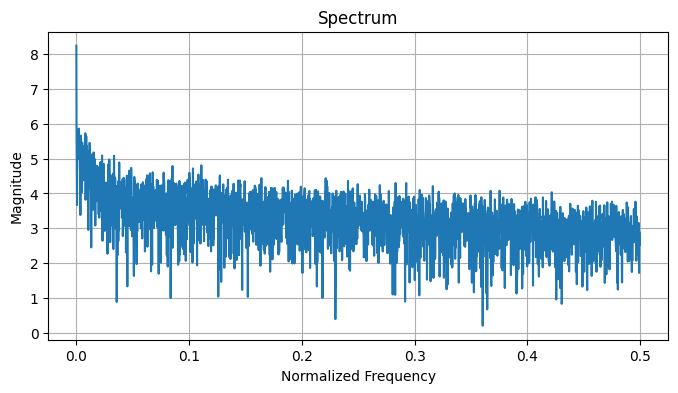

In [16]:
freq, spec = trace_to_log_spectrum(keys[0])

plt.figure(figsize=(8,4))
plt.plot(freq, spec)
plt.xlabel("Normalized Frequency")
plt.ylabel("Magnitude")
plt.title("Spectrum")
plt.grid(True)
plt.show()

## 转化为频谱能量

In [7]:
import numpy as np

def spectrum_band_stats(trace, remove_padding=True, log_scale=True):
    """
    输入一个 ±1 序列，返回全频、低频、中频、高频的平均能量。

    Parameters
    ----------
    trace : array-like
        ±1 序列（允许尾部0 padding）
    remove_padding : bool
        是否去除padding
    log_scale : bool
        是否使用log幅度谱

    Returns
    -------
    stats : dict
        {
            "all": ...,
            "low": ...,
            "mid": ...,
            "high": ...
        }
    """

    trace = np.asarray(trace, dtype=np.float32)

    if remove_padding:
        trace = trace[trace != 0]

    fft = np.fft.rfft(trace)

    # 幅度谱
    amp = np.abs(fft)
    power = np.abs(fft)**2

    if log_scale:
        amp = np.log1p(power +1e-8)

    n = len(power)

    low_end = n // 3
    mid_end = 2 * n // 3

    stats = {
        "all": amp.mean(),
        "low": amp[:low_end].mean(),
        "mid": amp[low_end:mid_end].mean(),
        "high": amp[mid_end:].mean()
    }

    return stats

### 只看单条轨迹能量分布n

{'all': 6.430661045600867, 'low': 7.3660616719461, 'mid': 6.271517792515699, 'high': 5.654403672340801}


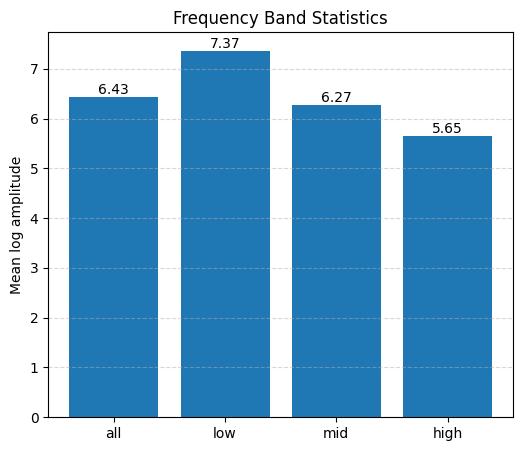

In [24]:
stats = spectrum_band_stats(keys[0])

print(stats)
import matplotlib.pyplot as plt

stats = spectrum_band_stats(keys[0])

labels = list(stats.keys())
values = list(stats.values())

plt.figure(figsize=(6,5))
bars = plt.bar(labels, values)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             y,
             f"{y:.2f}",
             ha="center",
             va="bottom")

plt.ylabel("Mean log amplitude")
plt.title("Frequency Band Statistics")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 看整个第0类的增强轨迹

In [10]:
cls = 0

stats_list = [
    spectrum_band_stats(trace)
    for trace in keys[labels == cls]
]

stats = {
    k: np.mean([s[k] for s in stats_list])
    for k in ["all", "low", "mid", "high"]
}

print(stats)

{'all': 6.199907002735812, 'low': 6.863508489251238, 'mid': 6.153960571021816, 'high': 5.582976637893013}


In [11]:
print(len(stats_list)) ## 2500*2=5000左右

4996


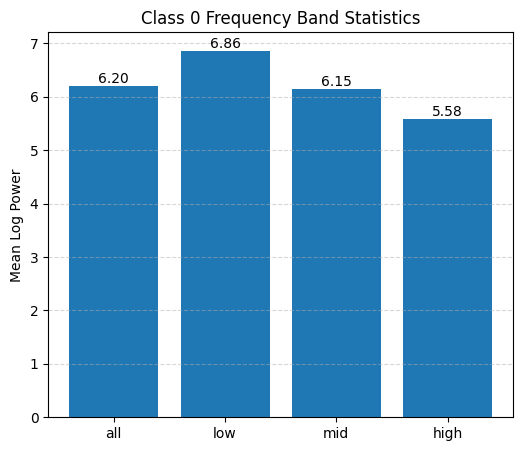

In [12]:
import matplotlib.pyplot as plt

labels_name = list(stats.keys())
values = list(stats.values())

plt.figure(figsize=(6,5))
bars = plt.bar(labels_name, values)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             y,
             f"{y:.2f}",
             ha="center",
             va="bottom")

plt.ylabel("Mean Log Power")
plt.title(f"Class {cls} Frequency Band Statistics")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()